In [1]:
import mitsuba as mi
import drjit as dr
import matplotlib.pyplot as plt

mi.set_variant('cuda_ad_rgb')

In [2]:
# scene = mi.load_file('./teapot/scene.xml')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..13.094981].


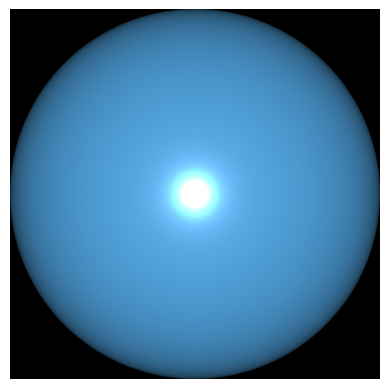

In [3]:
scene = mi.load_dict({
    "type": "scene",
    "myintegrator": {
        "type": "path",
    },
    "mysensor": {
        "type": "orthographic",
        "near_clip": 0.000000000000000000000000000000000000000000001,
        "far_clip": 1000.0,
        "to_world": mi.ScalarTransform4f.look_at(origin=[0.0, 0.0, 1.0],
                                                 target=[0.0, 0.0, 0.0],
                                                 up=[0.0, 1.0, 0.0]),
        "myfilm": {
            "type": "hdrfilm",
            "rfilter": {
                "type": "box"
            },
            "width": 1000,
            "height": 1000,
        },
        "mysampler": {
            "type": "independent",
            "sample_count": 4,
        },
    },
    "myemitter": {
        'type': 'directional',
        'direction': [0.0, 0.0, -1.0],
        'irradiance': {
            'type': 'rgb',
            'value': 8.0,
        }
    },
    "myshape": {
        "type": "sphere",
        "radius": 1,
        "mybsdf": {
            'type': 'principled',
            'base_color': {
                'type': 'rgb',
                'value': [0.1, 0.5, 1.0]
            },
            'metallic': 0.7,
            'specular': 0.6,
            'roughness': 0.2,
            'spec_tint': 0.4,
            'anisotropic': 0.5,
            'sheen': 0.3,
            'sheen_tint': 0.2,
            'clearcoat': 0.6,
            'clearcoat_gloss': 0.3,
            'spec_trans': 0.0
        }
    },
})

image = mi.render(scene, spp=256)

plt.axis("off")
plt.imshow(image ** (1.0 / 2.2)); # approximate sRGB tonemapping

In [4]:
params = mi.traverse(scene)
# print(params)
keys=['myshape.bsdf.clearcoat.value', 'myshape.bsdf.clearcoat_gloss.value', 'myshape.bsdf.metallic.value', 'myshape.bsdf.specular', 'myshape.bsdf.roughness.value', 'myshape.bsdf.base_color.value', 'myshape.bsdf.anisotropic.value', 'myshape.bsdf.spec_tint.value', 'myshape.bsdf.sheen.value', 'myshape.bsdf.sheen_tint.value']
params.keep(keys)
# print(params)
# print(params['myemitter.irradiance.value'])

dr.enable_grad(params)

opt = mi.ad.Adam(lr=0.05, params=params)
for key in keys:
    opt[key] = params[key]
params.update(opt);

In [5]:
def mse(image, image_ref):
    return dr.mean(dr.square(image - image_ref))

def mse_multiple(images, images_ref):
    images = dr.concat(images)
    images_ref = dr.concat(images_ref)
    return dr.mean(dr.square(images - images_ref))

# res= mse_multiple([image, image], [image, image])
# print(type(res))
# print(res)


In [6]:
image_ref = mi.Bitmap('merlDB_example/rendered_frames/light-red-paint0.png')

image_ref = image_ref.convert(mi.Bitmap.PixelFormat.RGB, mi.Bitmap.Float32, False)

image_ref = mi.TensorXf(image_ref)

In [7]:
from tqdm import trange  # or tqdm(range(...))

iteration_count = 100
errors = []
for it in trange(iteration_count, desc="Optimizing"):
    # Perform a (noisy) differentiable rendering of the scene
    image = mi.render(scene, params, spp=32)

    # Evaluate the objective function from the current rendered image
    loss = mse(image, image_ref)
    errors.append(loss.item())

    # Backpropagate through the rendering process
    dr.backward(loss)

    # Optimizer: take a gradient descent step
    opt.step()

    # Post-process the optimized parameters to ensure legal color values.
    for key in keys:
        if key != 'myemitter.irradiance.value':
            opt[key] = dr.clip(opt[key], 0.0, 1.0)

    # Update the scene state to the new optimized values
    params.update(opt)

    # Track the difference between the current color and the true value
    # err_ref = dr.sum(dr.square(param_ref - params[key]))
    # print(f"Iteration {it:02d}: parameter error = {err_ref}", end='\r')
    # errors.append(dr.slice(err_ref))

print('\nOptimization complete.')


Optimizing:   0%|          | 0/100 [00:00<?, ?it/s]

jit_flush_malloc_cache(): Dr.Jit exhausted the available memory and had to flush its allocation cache to free up additional memory. This is an expensive operation and will have a negative effect on performance. You may want to change your computation so that it uses less memory. This warning will only be displayed once.
Optimizing:   0%|          | 0/100 [00:00<?, ?it/s]


RuntimeError: jit_malloc(): out of memory! Could not allocate 134217728 bytes of device memory.

In [ ]:
image_final = mi.render(scene, spp=128)
mi.util.convert_to_bitmap(image_final)

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [1000, 1000],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 2.86 MiB of image data ]
]

In [ ]:
image_diff = image_final - image_ref
mi.util.convert_to_bitmap(image_diff)

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [1000, 1000],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 2.86 MiB of image data ]
]

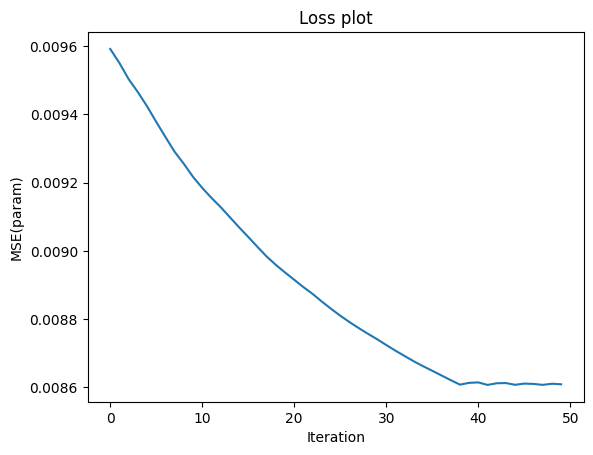

In [ ]:
import matplotlib.pyplot as plt
plt.plot(errors)
plt.xlabel('Iteration'); plt.ylabel('MSE(param)'); plt.title('Loss plot');
plt.show()